# 은행 고객 데이터 분석

In [1]:
import os
import numpy as np
import pandas as pd
from plt_rcs import *
import hds

In [2]:
plt.rc(group='figure', figsize=(4,4))

In [6]:
os.getcwd()

'/Users/taehyunan/Desktop/Repo/SeSAC/Study/sesac_ml_dl_study_repo/project/code/ml_part2'

In [8]:
os.chdir('../../data')

In [9]:
[i for i in os.listdir() if 'Bank' in i]

['UniversalBank.csv', 'BankCustomer.txt']

In [10]:
df = pd.read_csv('BankCustomer.txt')

In [11]:
df.head()

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,0,15721585.0,Nkemakonam,593.0,Germany,Female,39.0,4.0,80927.56,2.0,0.0,0.0,108008.65,0.0
1,1,15802858.0,Smith,646.0,France,Female,24.0,1.0,0.00,2.0,1.0,1.0,140650.19,0.0
2,2,15767339.0,Chien,646.0,France,Male,36.0,3.0,142929.17,1.0,1.0,0.0,181461.46,0.0
3,3,15654060.0,Chukwudi,614.0,France,Male,44.0,2.0,0.00,2.0,0.0,1.0,140579.17,0.0
4,4,15771270.0,Cattaneo,678.0,Germany,Female,32.0,1.0,123309.52,1.0,1.0,0.0,100998.50,0.0


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               15000 non-null  int64  
 1   CustomerId       15000 non-null  float64
 2   Surname          15000 non-null  object 
 3   CreditScore      15000 non-null  float64
 4   Geography        14999 non-null  object 
 5   Gender           15000 non-null  object 
 6   Age              15000 non-null  float64
 7   Tenure           15000 non-null  float64
 8   Balance          15000 non-null  float64
 9   NumOfProducts    15000 non-null  float64
 10  HasCrCard        15000 non-null  float64
 11  IsActiveMember   15000 non-null  float64
 12  EstimatedSalary  15000 non-null  float64
 13  Exited           15000 non-null  float64
dtypes: float64(10), int64(1), object(3)
memory usage: 1.6+ MB


In [13]:
df.isna().sum()

id                 0
CustomerId         0
Surname            0
CreditScore        0
Geography          1
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

## 기술통계량 확인

In [14]:
df.describe().round(3)

,id,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,15000.000,1.500000e+04,15000.000,15000.000,15000.000,15000.000,15000.000,15000.000,15000.000,15000.000,15000.000
mean,7499.500,1.569121e+07,657.571,37.739,5.018,42423.243,1.582,0.780,0.503,117835.215,0.203
std,4330.271,1.857191e+05,72.774,8.208,2.778,59577.971,0.531,0.414,0.500,45201.460,0.402
min,0.000,1.567008e+05,431.000,18.000,0.000,0.000,1.000,0.000,0.000,11.580,0.000
25%,3749.750,1.563560e+07,601.000,32.000,3.000,0.000,1.000,1.000,0.000,83700.660,0.000
50%,7499.500,1.569074e+07,661.000,37.000,5.000,0.000,2.000,1.000,1.000,123570.820,0.000
75%,11249.250,1.575798e+07,708.000,42.000,7.000,109072.822,2.000,1.000,1.000,155876.060,0.000
max,14999.000,1.581564e+07,850.000,74.000,10.000,204017.400,4.000,1.000,1.000,199992.480,1.000


In [15]:
df.describe(include=object)

,Surname,Geography,Gender
count,15000,14999,15000
unique,759,3,2
top,Ch'iu,France,Male
freq,282,9053,8455


In [ ]:
# 결측값 포함하여 조회
df['Geography'].value_counts(dropna=False).sort_index()
# Geography
# France     9053
# Germany    2663
# Spain      3283
# NaN           1
# Name: count, dtype: int64

Geography
France     9053
Germany    2663
Spain      3283
NaN           1
Name: count, dtype: int64

In [20]:
df['Gender'].value_counts(dropna=False).sort_index()
# Gender
# Female    6545
# Male      8455
# Name: count, dtype: int64

Gender
Female    6545
Male      8455
Name: count, dtype: int64

In [21]:
df[['Geography', 'Gender']].value_counts(dropna=False).sort_index()

Geography  Gender
France     Female    3857
           Male      5196
Germany    Female    1274
           Male      1389
Spain      Female    1413
           Male      1870
NaN        Female       1
Name: count, dtype: int64

In [ ]:
pd.crosstab(index=df['Geography'], columns=df['Gender'], normalize='index')
# Gender	Female	    Male
# Geography		
# France	0.426047	0.573953
# Germany	0.478408	0.521592
# Spain	    0.430399	0.569601

Gender,Female,Male
Geography,,
France,0.426047,0.573953
Germany,0.478408,0.521592
Spain,0.430399,0.569601


## 데이터 전처리

In [23]:
df.columns

Index(['id', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender',
       'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

In [24]:
df = df.drop(columns=['id', 'Surname'])

In [26]:
df = df.set_index(keys='CustomerId')

In [27]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
CustomerId,,,,,,,,,,,
15721585.0,593.0,Germany,Female,39.0,4.0,80927.56,2.0,0.0,0.0,108008.65,0.0
15802858.0,646.0,France,Female,24.0,1.0,0.00,2.0,1.0,1.0,140650.19,0.0
15767339.0,646.0,France,Male,36.0,3.0,142929.17,1.0,1.0,0.0,181461.46,0.0
15654060.0,614.0,France,Male,44.0,2.0,0.00,2.0,0.0,1.0,140579.17,0.0
15771270.0,678.0,Germany,Female,32.0,1.0,123309.52,1.0,1.0,0.0,100998.50,0.0


In [29]:
df.columns = ['Credit', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance',
            'NumProd', 'HasCard', 'Active', 'Salary', 'Exited']

In [30]:
df.head()

,Credit,Geography,Gender,Age,Tenure,Balance,NumProd,HasCard,Active,Salary,Exited
CustomerId,,,,,,,,,,,
15721585.0,593.0,Germany,Female,39.0,4.0,80927.56,2.0,0.0,0.0,108008.65,0.0
15802858.0,646.0,France,Female,24.0,1.0,0.00,2.0,1.0,1.0,140650.19,0.0
15767339.0,646.0,France,Male,36.0,3.0,142929.17,1.0,1.0,0.0,181461.46,0.0
15654060.0,614.0,France,Male,44.0,2.0,0.00,2.0,0.0,1.0,140579.17,0.0
15771270.0,678.0,Germany,Female,32.0,1.0,123309.52,1.0,1.0,0.0,100998.50,0.0


## EDA

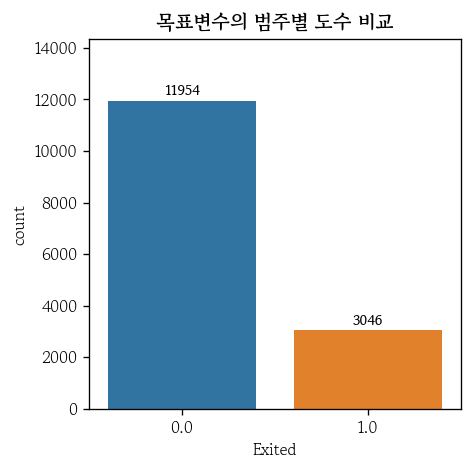

In [31]:
hds.plot.bar_freq(data=df, x='Exited')

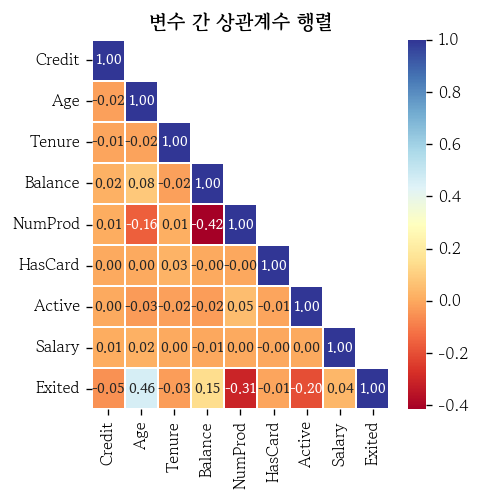

In [32]:
hds.plot.corr_heatmap(data=df)

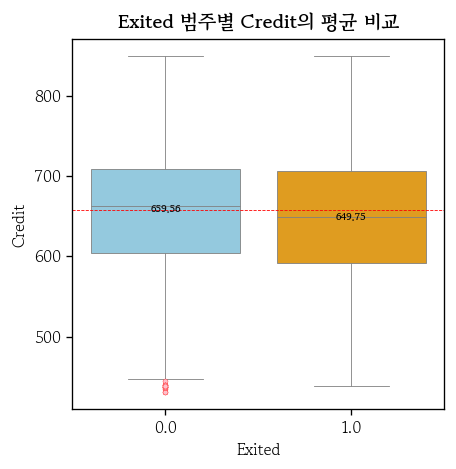

In [34]:
hds.plot.box_group(data=df, x='Exited', y='Credit', palette=['skyblue', 'orange'])

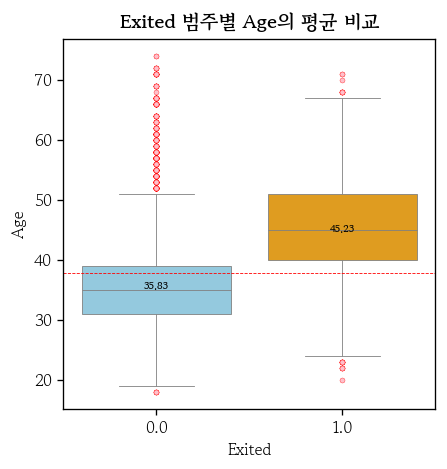

In [35]:
hds.plot.box_group(data=df, x='Exited', y='Age', palette=['skyblue', 'orange'])

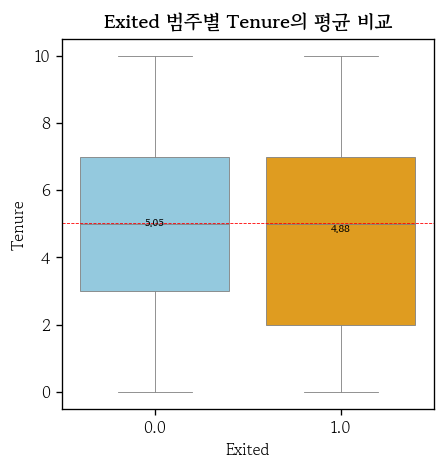

In [36]:
hds.plot.box_group(data=df, x='Exited', y='Tenure', palette=['skyblue', 'orange'])

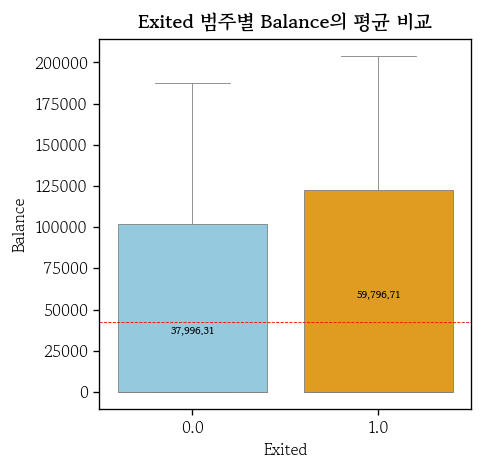

In [37]:
hds.plot.box_group(data=df, x='Exited', y='Balance', palette=['skyblue', 'orange'])

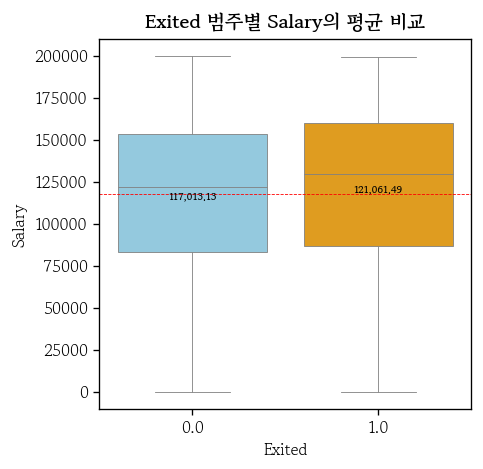

In [39]:
hds.plot.box_group(data=df, x='Exited', y='Salary', palette=['skyblue', 'orange'])

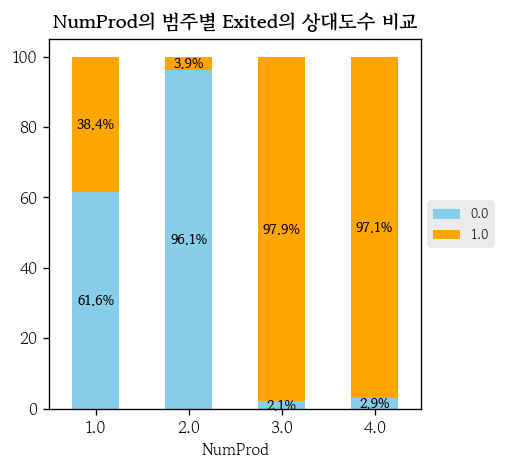

In [40]:
hds.plot.bar_stack_prop(
    data=df, x='NumProd', g='Exited',
    palette=['skyblue', 'orange']
)

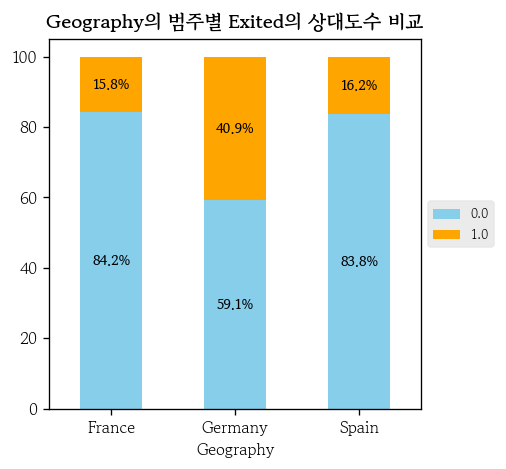

In [41]:
hds.plot.bar_stack_prop(
    data=df, x='Geography', g='Exited',
    palette=['skyblue', 'orange']
)

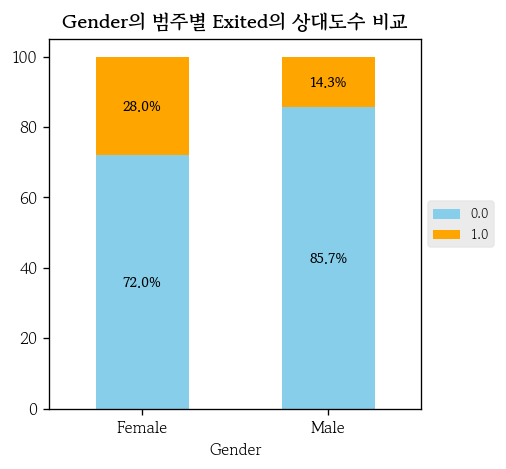

In [42]:
hds.plot.bar_stack_prop(
    data=df, x='Gender', g='Exited',
    palette=['skyblue', 'orange']
)

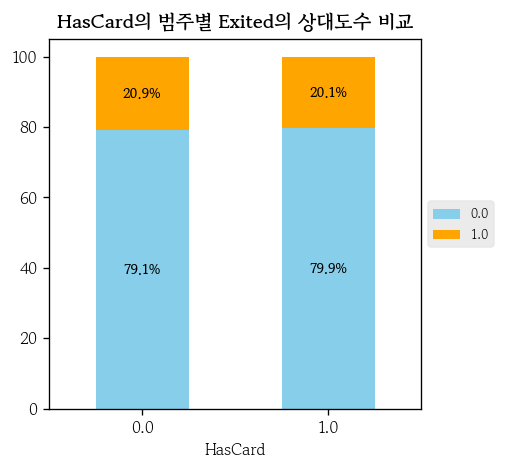

In [43]:
hds.plot.bar_stack_prop(
    data=df, x='HasCard', g='Exited',
    palette=['skyblue', 'orange']
)

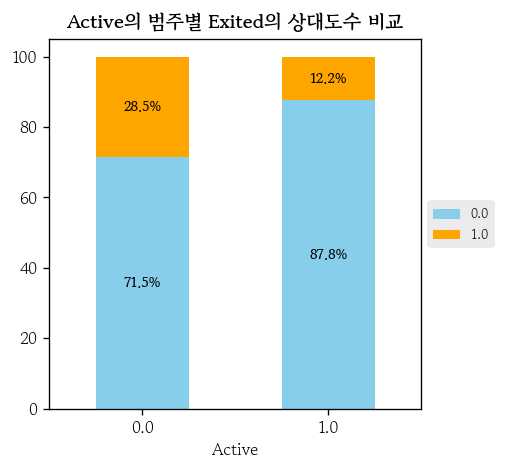

In [46]:
hds.plot.bar_stack_prop(
    data=df, x='Active', g='Exited',
    palette=['skyblue', 'orange']
)

## 연속형 입력변수 간 산점도 행렬 시각화

In [47]:
train_num = df.select_dtypes(include=[int, float]).drop(columns='Exited')

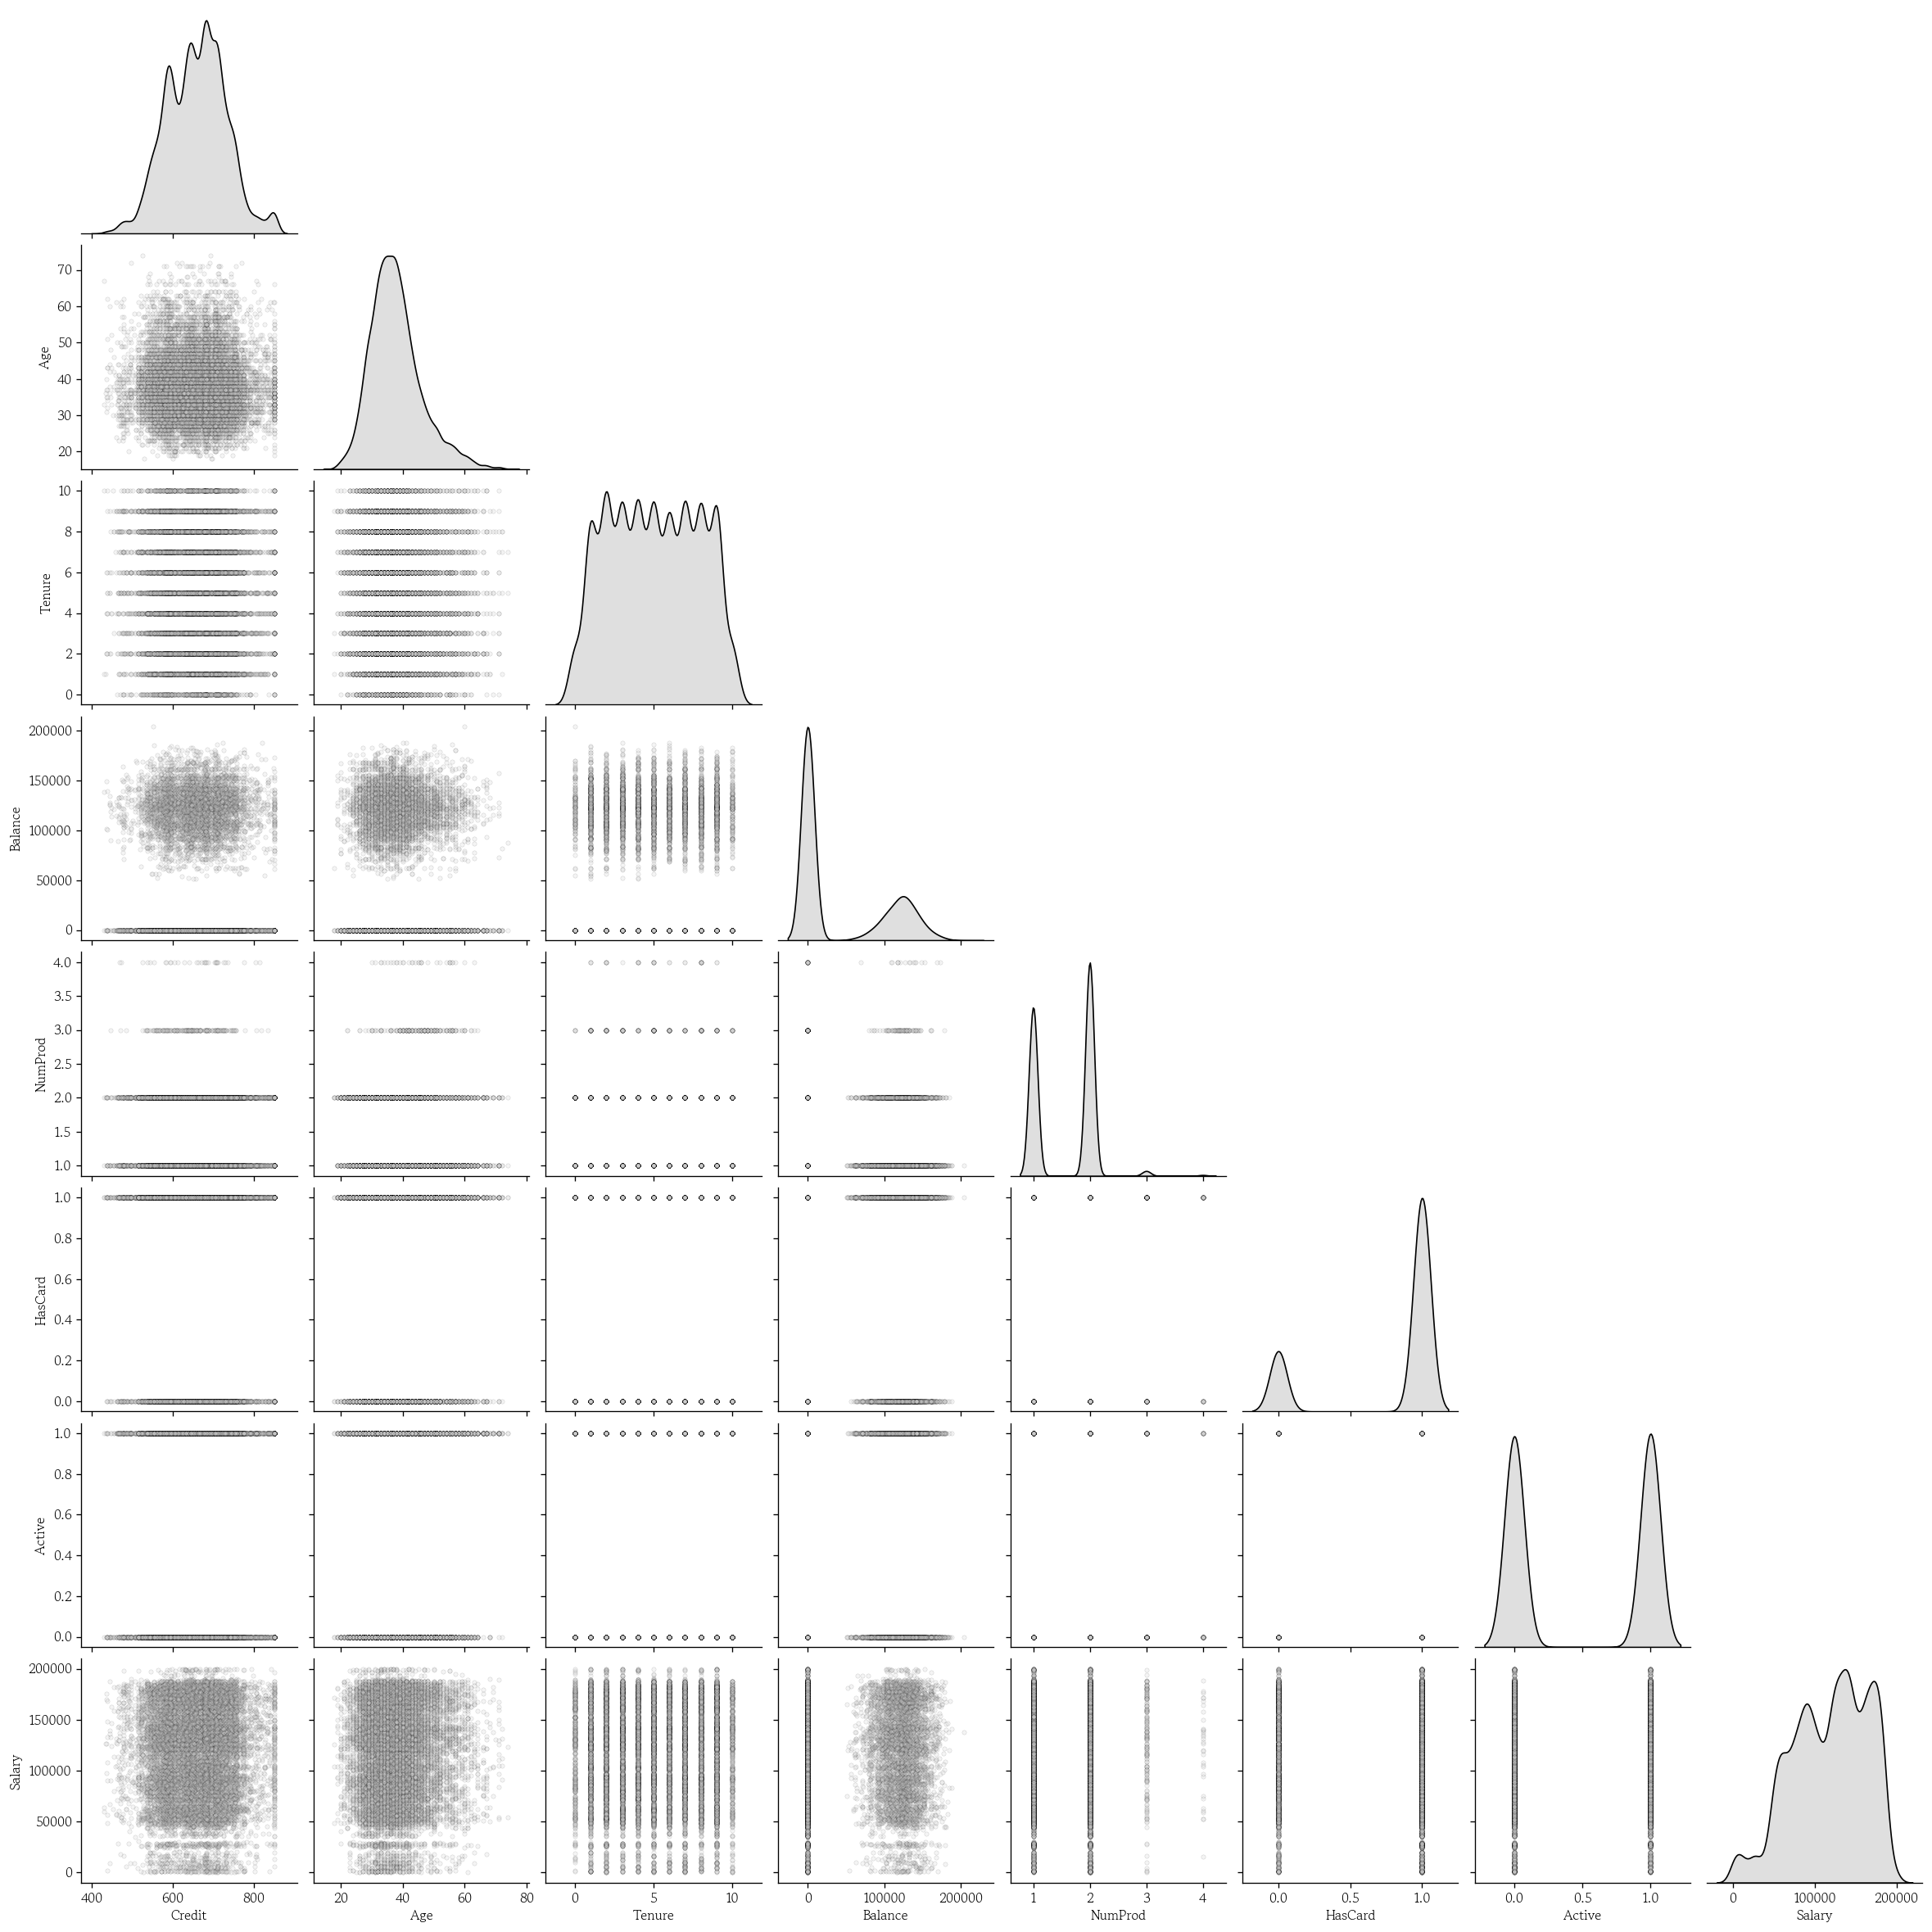

In [52]:
sns.pairplot(
    data=train_num, diag_kind='kde', corner=True,
    diag_kws={
        'color': '0.5',
        'edgecolor': '0'
    },
    plot_kws={
        'fc': '0.8',
        'ec': '0',
        's': 10,
        'alpha': 0.2
    }
)

plt.show()

## 원-핫 인코딩

In [55]:
df = pd.get_dummies(data=df, prefix='', prefix_sep='', dtype=int)

In [56]:
df.head()

,Credit,Age,Tenure,Balance,NumProd,HasCard,Active,Salary,Exited,France,Germany,Spain,Female,Male
CustomerId,,,,,,,,,,,,,,
15721585.0,593.0,39.0,4.0,80927.56,2.0,0.0,0.0,108008.65,0.0,0,1,0,1,0
15802858.0,646.0,24.0,1.0,0.00,2.0,1.0,1.0,140650.19,0.0,1,0,0,1,0
15767339.0,646.0,36.0,3.0,142929.17,1.0,1.0,0.0,181461.46,0.0,1,0,0,0,1
15654060.0,614.0,44.0,2.0,0.00,2.0,0.0,1.0,140579.17,0.0,1,0,0,0,1
15771270.0,678.0,32.0,1.0,123309.52,1.0,1.0,0.0,100998.50,0.0,0,1,0,1,0


In [57]:
df = df.drop(columns='Male').rename(columns={'Female': 'Gender'})

## 특성 행렬과 타겟 벡터로 분리

In [59]:
yvar = 'Exited'
X = df.drop(columns=yvar)
y = df[yvar].copy()
display(X)
display(y)

,Credit,Age,Tenure,Balance,NumProd,HasCard,Active,Salary,France,Germany,Spain,Gender
CustomerId,,,,,,,,,,,,
15721585.0,593.0,39.0,4.0,80927.56,2.0,0.0,0.0,108008.65,0,1,0,1
15802858.0,646.0,24.0,1.0,0.00,2.0,1.0,1.0,140650.19,1,0,0,1
15767339.0,646.0,36.0,3.0,142929.17,1.0,1.0,0.0,181461.46,1,0,0,0
15654060.0,614.0,44.0,2.0,0.00,2.0,0.0,1.0,140579.17,1,0,0,0
15771270.0,678.0,32.0,1.0,123309.52,1.0,1.0,0.0,100998.50,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...
15567855.0,727.0,43.0,8.0,105245.34,1.0,0.0,1.0,60552.44,0,1,0,0
15693906.0,607.0,32.0,2.0,0.00,2.0,1.0,1.0,181224.56,1,0,0,1
15757931.0,633.0,28.0,3.0,129743.75,1.0,1.0,1.0,162858.29,0,1,0,0


CustomerId
15721585.0    0.0
15802858.0    0.0
15767339.0    0.0
15654060.0    0.0
15771270.0    0.0
             ... 
15567855.0    0.0
15693906.0    0.0
15757931.0    0.0
15662908.0    0.0
15743545.0    0.0
Name: Exited, Length: 15000, dtype: float64

## 데이터셋 분할

In [60]:
from sklearn.model_selection import train_test_split

In [61]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=0, stratify=y
)

In [ ]:
X_train.shape
# (12000, 12)
X_valid.shape
# (3000, 12)

(12000, 12)

In [66]:
y_train.value_counts(normalize=True).sort_index()
# Exited
# 0.0    0.796917
# 1.0    0.203083
# Name: proportion, dtype: float64
y_valid.value_counts(normalize=True).sort_index()
# Exited
# 0.0    0.797
# 1.0    0.203
# Name: proportion, dtype: float64

Exited
0.0    0.797
1.0    0.203
Name: proportion, dtype: float64

## 외부 파일로 저장

In [67]:
os.getcwd()

'/Users/taehyunan/Desktop/Repo/SeSAC/Study/sesac_ml_dl_study_repo/project/data'

In [68]:
pd.to_pickle(obj={
    'X_train': X_train,
    'X_valid': X_valid,
    'y_train': y_train,
    'y_valid': y_valid,
}, filepath_or_buffer='Bank_Customer.pkl')